# Detect Faces and Blur Faces

This project implements an automated pipeline to detect human faces in images and videos and apply a blurring effect to anonymize them. The process uses a deep neural network (DNN) based on a pre-trained Single Shot Detector (SSD) model with a ResNet-10 backbone, trained using the Caffe framework. The blurring process helps in privacy preservation in multimedia content by masking identifiable features of individuals. The project supports face blurring in static images, real-time webcam streams, and pre-recorded video files. Additionally, it includes frame-per-second (FPS) overlay to monitor performance in real-time applications.

# Requirements

In [1]:
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt

# Load Models

This cell loads the pre-trained face detection model. The deploy.prototxt defines the model architecture, and res10_300x300_ssd_iter_140000_fp16.caffemodel contains the pre-trained weights. OpenCV’s dnn.readNetFromCaffe() function is used to load these resources, enabling the use of the deep learning-based face detector in the project.

In [2]:
# Define the path to the prototxt file using os.path.join for cross-platform compatibility
prototxt_path = os.path.join("models", "deploy.prototxt")

# Define the path to the caffemodel file using os.path.join for cross-platform compatibility
model_path = os.path.join("models", "res10_300x300_ssd_iter_140000_fp16.caffemodel")

# Load the pre-trained Caffe model from the specified files
# The readNetFromCaffe function loads the network architecture from the prototxt file and the trained weights from the caffemodel file
model = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)


# Face Detection and Blur Function

This cell defines the core function face_blur(), which:

1. Detects faces in the input image using the DNN model.
2. Calculates bounding boxes for each detected face.
3. Applies Gaussian blur to each face region individually.
4. Replaces the original face regions with the blurred versions in the image.

This function ensures the original image is not modified directly by working on a copy, preserving data integrity.

In [3]:
def face_blur(image: np.ndarray):
    # Create a copy of the input image to avoid modifying the original image (critical)
    image = image.copy()
    # Get the height and width of the image
    h, w = image.shape[:2] 

    # Define the kernel width and height for Gaussian blurring
    # Ensure they are odd numbers by performing a bitwise OR with 1
    kernel_width = (w // 7) | 1
    kernel_height = (h // 7) | 1

    # Create a blob from the image for input to the neural network
    blob = cv2.dnn.blobFromImage(image, 1.0, (300, 300), (104.0, 177.0, 123.0))

    # Set the input for the network
    model.setInput(blob)

    # Perform forward pass to get the output detections
    output = np.squeeze(model.forward())

    # Loop over all detections
    for i in range(0, output.shape[0]):
        # Get the confidence of the detection
        confidence = output[i, 2]

        # Proceed only if the confidence is above the threshold (0.4)
        if confidence > 0.4:
            # Get the bounding box coordinates and scale them to the original image size
            box = output[i, 3:7] * np.array([w, h, w, h])
            start_x, start_y, end_x, end_y = box.astype(int)

            # Extract the face region from the image
            face = image[start_y:end_y, start_x:end_x]

            # Apply Gaussian blur to the face region
            face = cv2.GaussianBlur(face, (kernel_width, kernel_height), 0)

            # Replace the original face region with the blurred face
            image[start_y:end_y, start_x:end_x] = face

    # Return the modified image with blurred faces
    return image


# Result on Image

This cell applies the face_blur() function to a static image (musk.jpg) and saves the output. The image is read, converted to the correct color format, processed, and written back to the output directory as musk_blurred.jpg.

In [4]:
# Define the path to the image file using os.path.join for cross-platform compatibility
image_path = os.path.join("images", "musk.jpg")

# Read the input image from the specified path
image = cv2.imread(image_path) 

# Convert the image from RGB to BGR format (as OpenCV uses BGR by default)
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) 

# Apply the face_blur function to the image to blur detected faces
image_face_blur = face_blur(image) 

cv2.imwrite(os.path.join("output", "musk_blurred.jpg"), image_face_blur)

True

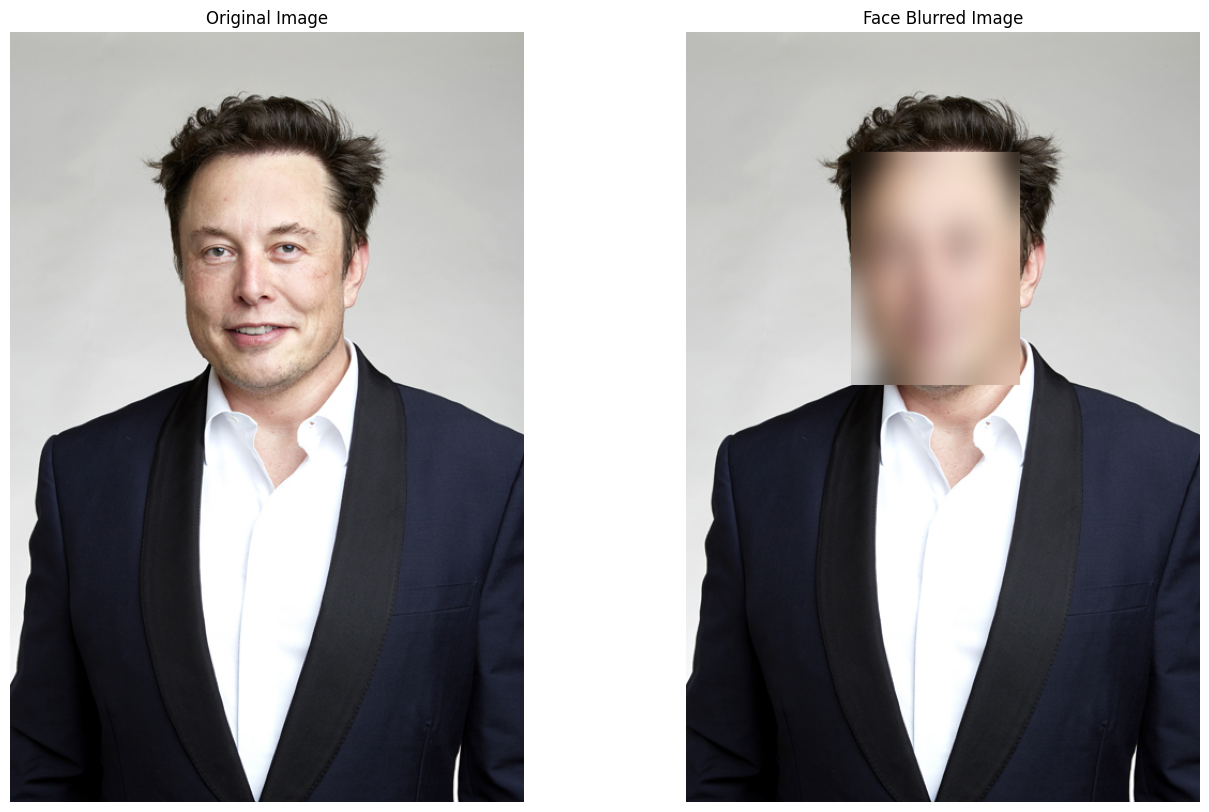

In [5]:
# Create a figure with specified size
plt.figure(figsize=(16, 10))

# Display the original image in the first subplot
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Display the face-blurred image in the second subplot
plt.subplot(1, 2, 2)
plt.imshow(image_face_blur)
plt.title("Face Blurred Image")
plt.axis("off")

plt.show()

# Result on WebCam Video Stream

This cell defines a utility function visualize_fps() to overlay the current FPS on the frame. It dynamically adjusts the text color based on whether the frame is grayscale or color, and ensures that the overlay is readable and informative in real-time processing.

In [6]:
def visualize_fps(image, fps: int):
    # Check if the image is grayscale or colored.
    # If it's grayscale, set the text color to white; if colored, set the text color to green.
    if len(np.shape(image)) < 3:
        text_color = (255, 255, 255)  # White color for grayscale images.
    else:
        text_color = (0, 255, 0)  # Green color for colored images.

    # Define the row size for the text placement.
    row_size = 20 
    # Define the left margin for the text placement.
    left_margin = 24 

    # Set the font size and thickness for the text.
    font_size = 1
    font_thickness = 2

    # Format the FPS value into a string for displaying.
    fps_text = "FPS = {:.1f}".format(fps)
    # Set the text location on the image.
    text_location = (left_margin, row_size)
    
    # Place the FPS text on the image.
    cv2.putText(
        image,
        fps_text,
        text_location,
        cv2.FONT_HERSHEY_PLAIN,
        font_size,
        text_color,
        font_thickness,
    )

    # Return the modified image with the FPS text.
    return image


This cell runs the face detection and blurring process on a live webcam feed. Key highlights:

1. Captures frames using cv2.VideoCapture(0).
2. Applies resizing, blurring, and FPS overlay.
3. Displays the modified stream in a real-time window.
4. Continuously calculates FPS to monitor processing efficiency.
5. Loop exits gracefully upon pressing the Esc key.

This section demonstrates the real-time capability of the model and its practical application in privacy-sensitive surveillance or broadcasting.



In [7]:
# # Constants for camera settings
# CAMERA_DEVICE_ID = 0  # ID for the camera device
# IMAGE_WIDTH = 800  # Width of the captured image
# IMAGE_HEIGHT = 600  # Height of the captured image
# fps = 0  # Initial Frames Per Second (FPS) value

# if __name__ == "__main__":  # Ensures that the code only runs when executed directly
#     try:
#         cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  # Initialize video capture with the specified camera device ID

#         while True:  # Infinite loop to continuously capture frames
#             start_time = time.time()  # Record the start time to calculate FPS

#             _, frame = cap.read()  # Capture a single frame from the camera

#             frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions
#             frame = face_blur(frame)  # Apply the face_blur function to the frame

#             # Display the frame with FPS overlay
#             cv2.imshow("frame", visualize_fps(frame, fps)) 

#             end_time = time.time()  # Record the end time to calculate FPS

#             # Calculate the time taken to process the frame
#             seconds = end_time - start_time
#             # Calculate FPS based on the time taken to process the frame
#             fps = 1.0 / seconds

#             # Break the loop if the 'Esc' key (ASCII 27) is pressed
#             if cv2.waitKey(33) == 27:  
#                 break
#     except Exception as e:  # Handle exceptions that may occur
#         print(e)  # Print the exception message
#     finally:
#         cv2.destroyAllWindows()  # Close all OpenCV windows
#         cap.release()  # Release the camera resource


This final cell applies the face blurring pipeline to a pre-recorded video (Jobs_2.mp4). It:

1. Reads the video file and processes each frame similarly to the webcam stream.
2. Uses time.sleep() to match a consistent target frame rate (30 FPS).
3. Displays each processed frame with a live FPS counter.
4. Allows the user to exit the video early by pressing Esc.

This component shows the versatility of the model when applied to offline video content, useful for batch processing and post-editing.

In [8]:
# Define the path to the video file using os.path.join for cross-platform compatibility
CAMERA_DEVICE_ID = os.path.join("videos", "Jobs_2.mp4")
# Constants for video settings
IMAGE_WIDTH = 1000  # Width of the displayed image
IMAGE_HEIGHT = 600  # Height of the displayed image
fps = 0  # Initial Frames Per Second (FPS) value
FRAME_RATE = 30  # Desired frame rate
DURATION = 1 / FRAME_RATE  # Duration of each frame

if __name__ == "__main__":  # Ensures that the code only runs when executed directly
    try:
        cap = cv2.VideoCapture(CAMERA_DEVICE_ID)  # Initialize video capture with the specified video file path
        output_path = os.path.join("output", "video_face_blurred.mp4")
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(
            output_path, fourcc, FRAME_RATE, (IMAGE_WIDTH, IMAGE_HEIGHT)
        )
        
        while True:  # Infinite loop to continuously capture frames
            start_time = time.time() # Record the start time to calculate FPS

            _, frame = cap.read()  # Capture a single frame from the video
            frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))  # Resize the frame to the specified dimensions
            frame = face_blur(frame)  # Apply the face_blur function to the frame

            end_time = time.time() # Record the end time to calculate FPS
            seconds = end_time - start_time # Calculate the time taken to process the frame

            if seconds < DURATION:  # If the processing time is less than the desired frame duration, wait for the remaining time
                time.sleep(DURATION - seconds)

            seconds = time.time() - start_time # Recalculate the time taken to process the frame including sleep time
            fps = 1.0 / seconds  # Calculate FPS based on the time taken to process the frame

            # Display the frame with FPS overlay
            cv2.imshow("frame", visualize_fps(frame, fps))
            out.write(frame)
            # Break the loop if the 'Esc' key (ASCII 27) is pressed
            if cv2.waitKey(33) == 27:
                break
    except Exception as e:  # Handle exceptions that may occur
        print(e)  # Print the exception message
    finally:
        cv2.destroyAllWindows()  # Close all OpenCV windows
        cap.release()  # Release the video capture resource
        out.release()

OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4152: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'



Through a combination of deep learning and image processing techniques, this project effectively demonstrates how face anonymization can be achieved in a variety of multimedia formats. It bridges practical concerns such as privacy protection with technical implementation, offering reusable, modular code for both real-time and batch processing scenarios.